# 0. 미션 개요

뉴스 문서를 20개의 카테고리로 분류한 News Group 20 데이터를 사용하여, 텍스트 데이터를 입력으로 받아 뉴스의 카테고리를 예측하는 딥러닝 모델을 구현

# 1. 라이브러리 import 및 환경 설정

In [1]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 74.2 MB/s eta 0:00:00:00:0100:01


In [62]:
import os
import re
import random
import zipfile
import urllib.request
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
nltk.download('punkt')
nltk.download('stopwords')

from nltk.corpus import stopwords

from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

from gensim.models import Word2Vec, FastText
from gensim.utils import simple_preprocess

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from IPython.display import display

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [63]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


# 2. 데이터 로드 및 전처리

## - 데이터 로드

In [64]:
news_data = fetch_20newsgroups(
    subset='all',
    remove=('headers', 'footers', 'quotes')
)

texts = news_data.data
labels = news_data.target
target_names = news_data.target_names

print("전체 문서 수:", len(texts))
print("클래스 수:", len(target_names))
print("첫 번째 문서 예시:\n")
print(texts[0][:1000])
print("\n첫 번째 라벨:", labels[0], target_names[labels[0]])

전체 문서 수: 18846
클래스 수: 20
첫 번째 문서 예시:



I am sure some bashers of Pens fans are pretty confused about the lack
of any kind of posts about the recent Pens massacre of the Devils. Actually,
I am  bit puzzled too and a bit relieved. However, I am going to put an end
to non-PIttsburghers' relief with a bit of praise for the Pens. Man, they
are killing those Devils worse than I thought. Jagr just showed you why
he is much better than his regular season stats. He is also a lot
fo fun to watch in the playoffs. Bowman should let JAgr have a lot of
fun in the next couple of games since the Pens are going to beat the pulp out of Jersey anyway. I was very disappointed not to see the Islanders lose the final
regular season game.          PENS RULE!!!



첫 번째 라벨: 10 rec.sport.hockey


In [65]:
# 클래스 별 문서 개수
label_counts = pd.Series(labels).value_counts().sort_index()
label_df = pd.DataFrame({
    "class_id": range(len(target_names)),
    "class_name": target_names,
    "count": label_counts.values
})
label_df.head()

,class_id,class_name,count
0,0,alt.atheism,799
1,1,comp.graphics,973
2,2,comp.os.ms-windows.misc,985
3,3,comp.sys.ibm.pc.hardware,982
4,4,comp.sys.mac.hardware,963


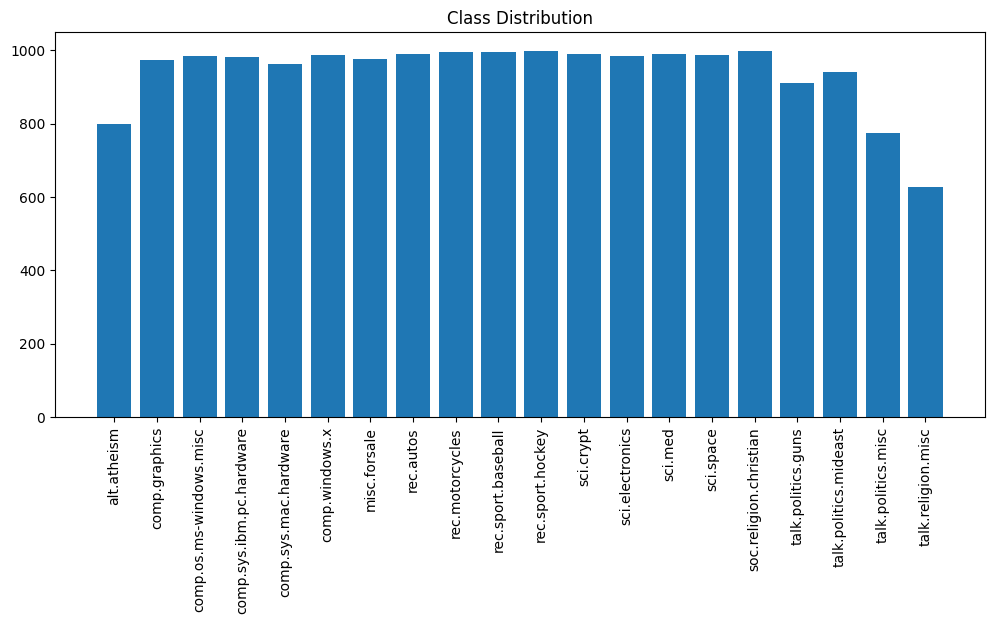

In [66]:
# 클래스별 문서 개수 시각화
plt.figure(figsize=(12, 5))
plt.bar(label_df["class_name"], label_df["count"])
plt.xticks(rotation=90)
plt.title("Class Distribution")
plt.show()

## - 기본 전처리

In [ ]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text)

    # 메일/뉴스 헤더 제거
    lines = text.split("\n")
    cleaned_lines = []

    for line in lines:
        line_stripped = line.strip().lower()

        if re.match(
            r"^(from|subject|organization|lines|reply-to|article-i.d.|article-id|"
            r"nntp-posting-host|distribution|keywords|summary|originator|sender|"
            r"date|expires|references|xref|path):",
            line_stripped
        ):
            continue

        # 인용문 제거
        if line.strip().startswith(">"):
            continue

        cleaned_lines.append(line)

    text = "\n".join(cleaned_lines)

    # 이메일 주소 제거
    text = re.sub(r"\S+@\S+", " ", text)

    # URL 제거
    text = re.sub(r"http\S+|www\.\S+", " ", text)

    # 소문자화
    text = text.lower()

    # 특수문자 제거
    text = re.sub(r"[^a-z0-9\s]", " ", text)

    # 공백 정리
    text = re.sub(r"\s+", " ", text).strip()

    return text


def preprocess_text(text, remove_stopwords=False):
    text = clean_text(text)
    tokens = simple_preprocess(text, deacc=True, min_len=1)

    if remove_stopwords:
        tokens = [token for token in tokens if token not in stop_words]

    if len(tokens) == 0:
        tokens = ["<UNK>"]

    return tokens

In [68]:
sample_text = texts[0]
print("원문:\n", sample_text[:500])
print("\n전처리 후 토큰:\n", preprocess_text(sample_text)[:30])

원문:
 

I am sure some bashers of Pens fans are pretty confused about the lack
of any kind of posts about the recent Pens massacre of the Devils. Actually,
I am  bit puzzled too and a bit relieved. However, I am going to put an end
to non-PIttsburghers' relief with a bit of praise for the Pens. Man, they
are killing those Devils worse than I thought. Jagr just showed you why
he is much better than his regular season stats. He is also a lot
fo fun to watch in the playoffs. Bowman should let JAgr have a

전처리 후 토큰:
 ['i', 'am', 'sure', 'some', 'bashers', 'of', 'pens', 'fans', 'are', 'pretty', 'confused', 'about', 'the', 'lack', 'of', 'any', 'kind', 'of', 'posts', 'about', 'the', 'recent', 'pens', 'massacre', 'of', 'the', 'devils', 'actually', 'i', 'am']


## - 데이터 분할

In [69]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    texts,
    labels,
    test_size=0.2,
    random_state=SEED,
    stratify=labels
)

train_texts, valid_texts, train_labels, valid_labels = train_test_split(
    train_texts,
    train_labels,
    test_size=0.125,
    random_state=SEED,
    stratify=train_labels
)

print("train:", len(train_texts))
print("valid:", len(valid_texts))
print("test :", len(test_texts))

train: 13191
valid: 1885
test : 3770


In [70]:
train_sentences = [preprocess_text(text, remove_stopwords=False) for text in train_texts]
valid_sentences = [preprocess_text(text, remove_stopwords=False) for text in valid_texts]
test_sentences  = [preprocess_text(text, remove_stopwords=False) for text in test_texts]

print(train_sentences[0][:30])

['i', 'am', 'in', 'the', 'market', 'to', 'buy', 'a', 'used', 'car', 'i', 'am', 'particularly', 'interested', 'in', 'the', 'pontiac', 'bonneville', 'my', 'budget', 'is', 'between', 'thousand', 'would', 'i', 'be', 'able', 'to', 'afford', 'an']


## - 단어 사전 구축 및 정수 인코딩

In [71]:
counter = Counter()
for sent in train_sentences:
    counter.update(sent)

min_freq = 2
max_vocab_size = 30000

vocab = {
    "<PAD>": 0,
    "<UNK>": 1
}

for word, freq in counter.most_common(max_vocab_size):
    if freq >= min_freq and word not in vocab:
        vocab[word] = len(vocab)

idx2word = {idx: word for word, idx in vocab.items()}

print("vocab size:", len(vocab))
print("PAD index:", vocab["<PAD>"])
print("UNK index:", vocab["<UNK>"])

vocab size: 30001
PAD index: 0
UNK index: 1


## - 패딩 처리

In [72]:
train_lengths = [len(sent) for sent in train_sentences]
print("평균 길이:", np.mean(train_lengths))
print("최대 길이:", np.max(train_lengths))
print("95분위 길이:", np.percentile(train_lengths, 95))

평균 길이: 188.13577439163066
최대 길이: 20046
95분위 길이: 557.0


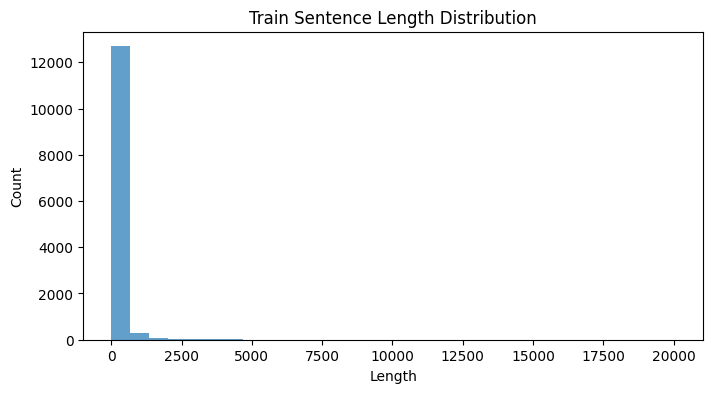

In [73]:
plt.figure(figsize=(8, 4))
plt.hist(train_lengths, bins=30, alpha=0.7)
plt.title("Train Sentence Length Distribution")
plt.xlabel("Length")
plt.ylabel("Count")
plt.show()

In [74]:
max_len = max(400, int(np.percentile(train_lengths, 95)))
print("max_len:", max_len)

max_len: 557


In [75]:
def encode_text(tokens, vocab, max_len):
    seq = [vocab.get(token, vocab["<UNK>"]) for token in tokens]
    seq = seq[:max_len]
    seq += [vocab["<PAD>"]] * (max_len - len(seq))
    return seq

X_train_seq = np.array([encode_text(tokens, vocab, max_len) for tokens in train_sentences], dtype=np.int64)
X_valid_seq = np.array([encode_text(tokens, vocab, max_len) for tokens in valid_sentences], dtype=np.int64)
X_test_seq  = np.array([encode_text(tokens, vocab, max_len) for tokens in test_sentences], dtype=np.int64)

y_train = np.array(train_labels, dtype=np.int64)
y_valid = np.array(valid_labels, dtype=np.int64)
y_test  = np.array(test_labels, dtype=np.int64)

print(X_train_seq.shape, X_valid_seq.shape, X_test_seq.shape)

(13191, 557) (1885, 557) (3770, 557)


# 3. 모델별 데이터 정의

## - 모델별 임베딩

In [76]:
embedding_dim = 200

word2vec_model = Word2Vec(
    sentences=train_sentences,
    vector_size=embedding_dim,
    window=8,
    min_count=2,
    workers=4,
    sg=1,
    epochs=20,
    negative=10,
    sample=1e-5
)

fasttext_model = FastText(
    sentences=train_sentences,
    vector_size=embedding_dim,
    window=8,
    min_count=2,
    workers=4,
    sg=1,
    epochs=20,
    negative=10,
    sample=1e-5
)

print("Word2Vec and FastText training complete")

Word2Vec and FastText training complete


In [77]:
GLOVE_URL = "https://nlp.stanford.edu/data/glove.6B.zip"
GLOVE_ZIP = "glove.6B.zip"
GLOVE_FILE = f"glove.6B.{embedding_dim}d.txt"

if not os.path.exists(GLOVE_FILE):
    urllib.request.urlretrieve(GLOVE_URL, GLOVE_ZIP)
    with zipfile.ZipFile(GLOVE_ZIP, 'r') as zip_ref:
        zip_ref.extractall(".")

In [78]:
def load_glove_model(glove_file):
    glove_dict = {}
    with open(glove_file, "r", encoding="utf-8") as f:
        for line in f:
            values = line.split()
            word = values[0]
            vector = np.asarray(values[1:], dtype="float32")
            glove_dict[word] = vector
    return glove_dict

glove_dict = load_glove_model(GLOVE_FILE)
print("GloVe vocab size:", len(glove_dict))

GloVe vocab size: 400000


## - 임베딩 행렬

In [79]:
def build_embedding_matrix(vocab, embedding_dim, embedding_source, source_type="gensim"):
    embedding_matrix = np.random.normal(scale=0.6, size=(len(vocab), embedding_dim))
    embedding_matrix[vocab["<PAD>"]] = np.zeros(embedding_dim)

    for word, idx in vocab.items():
        if word in ["<PAD>", "<UNK>"]:
            continue

        if source_type == "gensim":
            if word in embedding_source.wv:
                embedding_matrix[idx] = embedding_source.wv[word]
        elif source_type == "glove":
            if word in embedding_source:
                embedding_matrix[idx] = embedding_source[word]

    return embedding_matrix.astype(np.float32)

word2vec_matrix = build_embedding_matrix(vocab, embedding_dim, word2vec_model, source_type="gensim")
fasttext_matrix = build_embedding_matrix(vocab, embedding_dim, fasttext_model, source_type="gensim")
glove_matrix = build_embedding_matrix(vocab, embedding_dim, glove_dict, source_type="glove")

print(word2vec_matrix.shape, fasttext_matrix.shape, glove_matrix.shape)

(30001, 200) (30001, 200) (30001, 200)


## - 데이터셋

In [80]:
class TextDataset(Dataset):
    def __init__(self, X, y, pad_idx=0):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
        self.pad_idx = pad_idx

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx]
        y = self.y[idx]
        length = int((x != self.pad_idx).sum().item())
        length = max(1, length)
        return x, y, length

## - 데이터 로더

In [81]:
train_dataset = TextDataset(X_train_seq, y_train)
valid_dataset = TextDataset(X_valid_seq, y_valid)
test_dataset  = TextDataset(X_test_seq, y_test)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=128, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=128, shuffle=False)

# 4. BiGRU 기반 텍스트 분류 모델 정의

In [82]:
class TextClassifierGRU(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_dim,
        output_dim,
        embedding_matrix=None,
        n_layers=1,
        bidirectional=True,
        dropout=0.3,
        freeze_embedding=False,
        pad_idx=0
    ):
        super().__init__()
        self.pad_idx = pad_idx

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=pad_idx
        )

        if embedding_matrix is not None:
            self.embedding.weight.data.copy_(torch.tensor(embedding_matrix))
            self.embedding.weight.requires_grad = not freeze_embedding

        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout if n_layers > 1 else 0.0
        )

        self.dropout = nn.Dropout(dropout)
        gru_output_dim = hidden_dim * 2 if bidirectional else hidden_dim
        self.fc = nn.Linear(gru_output_dim * 2, output_dim)

    def forward(self, x, lengths):
        mask = (x != self.pad_idx)
        embedded = self.embedding(x)

        packed = nn.utils.rnn.pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        packed_output, _ = self.gru(packed)
        output, _ = nn.utils.rnn.pad_packed_sequence(
            packed_output,
            batch_first=True,
            total_length=x.size(1)
        )

        mask_float = mask.unsqueeze(-1).float()
        sum_output = (output * mask_float).sum(dim=1)
        lengths_clamped = lengths.unsqueeze(1).float().clamp(min=1.0)
        mean_pool = sum_output / lengths_clamped

        output_masked = output.masked_fill(~mask.unsqueeze(-1), -1e9)
        max_pool, _ = output_masked.max(dim=1)

        concat = torch.cat([mean_pool, max_pool], dim=1)
        concat = self.dropout(concat)
        out = self.fc(concat)
        return out

# 5. 학습 및 평가 함수

In [83]:
class EarlyStopping:
    def __init__(self, patience=3, mode="max", min_delta=0.0):
        self.patience = patience
        self.mode = mode
        self.min_delta = min_delta
        self.best_score = None
        self.counter = 0
        self.should_stop = False

    def step(self, score):
        if self.best_score is None:
            self.best_score = score
            return True

        improved = score > self.best_score + self.min_delta if self.mode == "max" else score < self.best_score - self.min_delta

        if improved:
            self.best_score = score
            self.counter = 0
            return True
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
            return False

In [84]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0

    for X_batch, y_batch, len_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        len_batch = len_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch, len_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [85]:
def evaluate_loss_and_metrics(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    preds = []
    targets = []

    with torch.no_grad():
        for X_batch, y_batch, len_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            len_batch = len_batch.to(device)

            outputs = model(X_batch, len_batch)
            loss = criterion(outputs, y_batch)
            total_loss += loss.item()

            pred = torch.argmax(outputs, dim=1).cpu().numpy()
            preds.extend(pred)
            targets.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(targets, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(targets, preds, average="weighted", zero_division=0)
    return avg_loss, acc, prec, rec, f1

In [86]:
def run_rnn_experiment(
    name,
    embedding_matrix,
    train_loader,
    valid_loader,
    output_dim,
    hidden_dim=256,
    dropout=0.3,
    lr=5e-4,
    weight_decay=1e-4,
    epochs=12,
    freeze_embedding=False,
    scheduler_patience=1,
    early_stopping_patience=3
):
    model = TextClassifierGRU(
        vocab_size=len(vocab),
        embedding_dim=embedding_matrix.shape[1],
        hidden_dim=hidden_dim,
        output_dim=output_dim,
        embedding_matrix=embedding_matrix,
        bidirectional=True,
        dropout=dropout,
        freeze_embedding=freeze_embedding
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=scheduler_patience)
    early_stopper = EarlyStopping(patience=early_stopping_patience, mode="max")

    history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_f1": []}
    best_state_dict = None
    best_val_f1 = -1
    best_val_acc = -1

    for epoch in range(epochs):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc, val_prec, val_rec, val_f1 = evaluate_loss_and_metrics(model, valid_loader, criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_f1"].append(val_f1)

        scheduler.step(val_f1)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_val_acc = val_acc
            best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(
            f"[{name}] Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f} | "
            f"Val F1: {val_f1:.4f}"
        )

        early_stopper.step(val_f1)
        if early_stopper.should_stop:
            print(f"Early stopping triggered for {name}")
            break

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    return model, history, best_val_acc, best_val_f1

# 6. 비교 실험

## - 모델별 실험

In [87]:
model_w2v, history_w2v, val_acc_w2v, val_f1_w2v = run_rnn_experiment(
    name="Word2Vec",
    embedding_matrix=word2vec_matrix,
    train_loader=train_loader,
    valid_loader=valid_loader,
    output_dim=len(target_names),
    hidden_dim=256,
    dropout=0.3,
    lr=5e-4,
    epochs=12,
    freeze_embedding=False
)

[Word2Vec] Epoch 1/12 | Train Loss: 2.3618 | Val Loss: 1.7265 | Val Acc: 0.4318 | Val F1: 0.3748
[Word2Vec] Epoch 2/12 | Train Loss: 1.4659 | Val Loss: 1.3233 | Val Acc: 0.5862 | Val F1: 0.5615
[Word2Vec] Epoch 3/12 | Train Loss: 1.1130 | Val Loss: 1.0702 | Val Acc: 0.6653 | Val F1: 0.6572
[Word2Vec] Epoch 4/12 | Train Loss: 0.8934 | Val Loss: 0.9947 | Val Acc: 0.6859 | Val F1: 0.6825
[Word2Vec] Epoch 5/12 | Train Loss: 0.7506 | Val Loss: 0.9571 | Val Acc: 0.7019 | Val F1: 0.6964
[Word2Vec] Epoch 6/12 | Train Loss: 0.6254 | Val Loss: 0.9562 | Val Acc: 0.7082 | Val F1: 0.7088
[Word2Vec] Epoch 7/12 | Train Loss: 0.5225 | Val Loss: 0.9729 | Val Acc: 0.7029 | Val F1: 0.7044
[Word2Vec] Epoch 8/12 | Train Loss: 0.4414 | Val Loss: 0.9719 | Val Acc: 0.7040 | Val F1: 0.7060
[Word2Vec] Epoch 9/12 | Train Loss: 0.3457 | Val Loss: 1.0597 | Val Acc: 0.6976 | Val F1: 0.6939
Early stopping triggered for Word2Vec


In [88]:
model_ft, history_ft, val_acc_ft, val_f1_ft = run_rnn_experiment(
    name="FastText",
    embedding_matrix=fasttext_matrix,
    train_loader=train_loader,
    valid_loader=valid_loader,
    output_dim=len(target_names),
    hidden_dim=256,
    dropout=0.3,
    lr=5e-4,
    epochs=12,
    freeze_embedding=False
)

[FastText] Epoch 1/12 | Train Loss: 2.3887 | Val Loss: 1.8309 | Val Acc: 0.4175 | Val F1: 0.3823
[FastText] Epoch 2/12 | Train Loss: 1.5397 | Val Loss: 1.3935 | Val Acc: 0.5607 | Val F1: 0.5498
[FastText] Epoch 3/12 | Train Loss: 1.1471 | Val Loss: 1.1305 | Val Acc: 0.6525 | Val F1: 0.6420
[FastText] Epoch 4/12 | Train Loss: 0.9136 | Val Loss: 1.0409 | Val Acc: 0.6695 | Val F1: 0.6616
[FastText] Epoch 5/12 | Train Loss: 0.7657 | Val Loss: 1.0625 | Val Acc: 0.6642 | Val F1: 0.6632
[FastText] Epoch 6/12 | Train Loss: 0.6532 | Val Loss: 1.0081 | Val Acc: 0.6907 | Val F1: 0.6876
[FastText] Epoch 7/12 | Train Loss: 0.5433 | Val Loss: 1.0620 | Val Acc: 0.6923 | Val F1: 0.6908
[FastText] Epoch 8/12 | Train Loss: 0.4501 | Val Loss: 1.0472 | Val Acc: 0.6966 | Val F1: 0.6982
[FastText] Epoch 9/12 | Train Loss: 0.3744 | Val Loss: 1.2828 | Val Acc: 0.6568 | Val F1: 0.6531
[FastText] Epoch 10/12 | Train Loss: 0.3107 | Val Loss: 1.1779 | Val Acc: 0.6950 | Val F1: 0.6967
[FastText] Epoch 11/12 | Trai

In [89]:
model_glove, history_glove, val_acc_glove, val_f1_glove = run_rnn_experiment(
    name="GloVe",
    embedding_matrix=glove_matrix,
    train_loader=train_loader,
    valid_loader=valid_loader,
    output_dim=len(target_names),
    hidden_dim=256,
    dropout=0.3,
    lr=5e-4,
    epochs=12,
    freeze_embedding=False
)

[GloVe] Epoch 1/12 | Train Loss: 2.4485 | Val Loss: 1.8893 | Val Acc: 0.4074 | Val F1: 0.3705
[GloVe] Epoch 2/12 | Train Loss: 1.6694 | Val Loss: 1.4404 | Val Acc: 0.5358 | Val F1: 0.5103
[GloVe] Epoch 3/12 | Train Loss: 1.2721 | Val Loss: 1.2496 | Val Acc: 0.5995 | Val F1: 0.5832
[GloVe] Epoch 4/12 | Train Loss: 1.0417 | Val Loss: 1.1052 | Val Acc: 0.6488 | Val F1: 0.6441
[GloVe] Epoch 5/12 | Train Loss: 0.8703 | Val Loss: 1.0667 | Val Acc: 0.6631 | Val F1: 0.6566
[GloVe] Epoch 6/12 | Train Loss: 0.7368 | Val Loss: 1.0739 | Val Acc: 0.6631 | Val F1: 0.6595
[GloVe] Epoch 7/12 | Train Loss: 0.6044 | Val Loss: 1.0071 | Val Acc: 0.6828 | Val F1: 0.6822
[GloVe] Epoch 8/12 | Train Loss: 0.4900 | Val Loss: 1.0661 | Val Acc: 0.6796 | Val F1: 0.6785
[GloVe] Epoch 9/12 | Train Loss: 0.3992 | Val Loss: 1.0767 | Val Acc: 0.6923 | Val F1: 0.6877
[GloVe] Epoch 10/12 | Train Loss: 0.3230 | Val Loss: 1.1457 | Val Acc: 0.6875 | Val F1: 0.6872
[GloVe] Epoch 11/12 | Train Loss: 0.2533 | Val Loss: 1.2854

## - 학습 곡선 확인

In [90]:
def plot_history(history, title):
    plt.figure(figsize=(14, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Validation Loss")
    plt.title(f"{title} - Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history["val_f1"], label="Validation F1")
    plt.plot(history["val_acc"], label="Validation Accuracy")
    plt.title(f"{title} - Validation Metrics")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.legend()

    plt.tight_layout()
    plt.show()

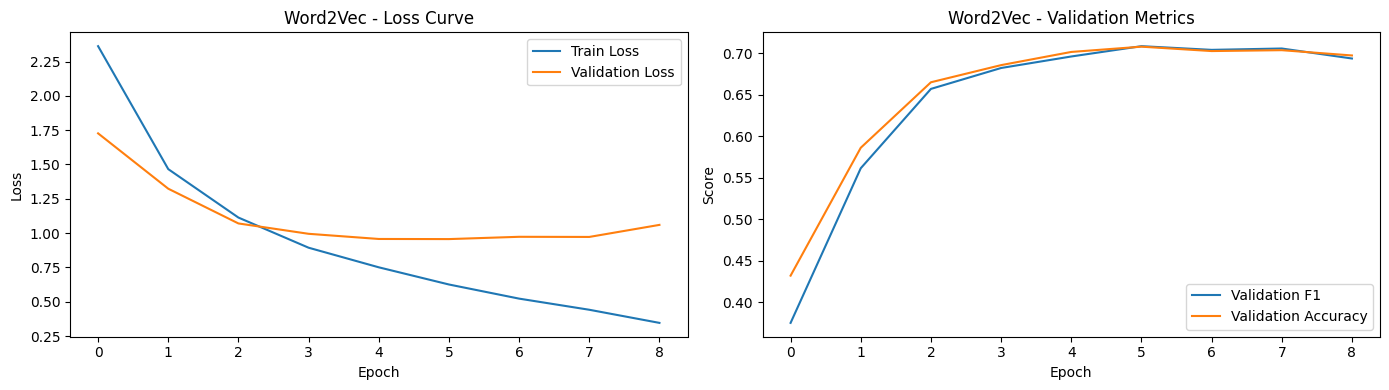

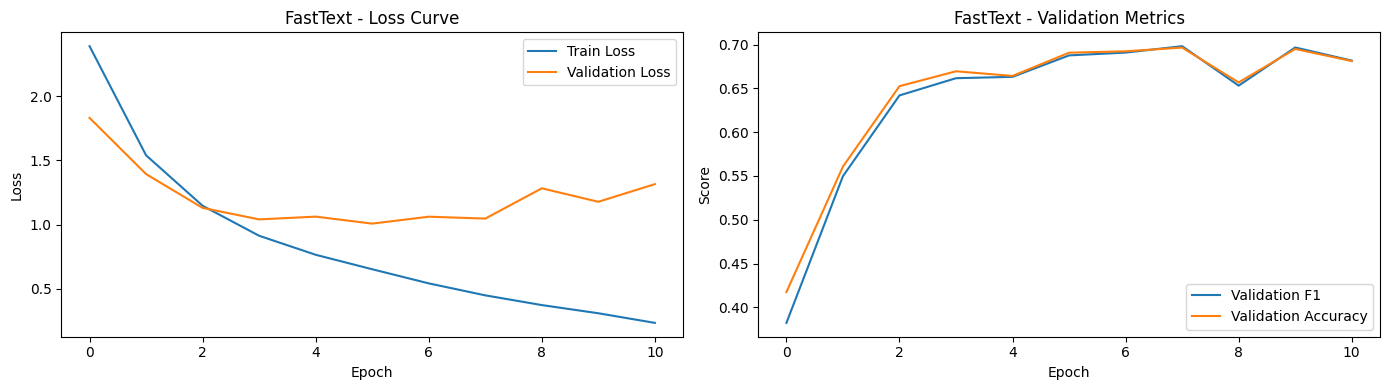

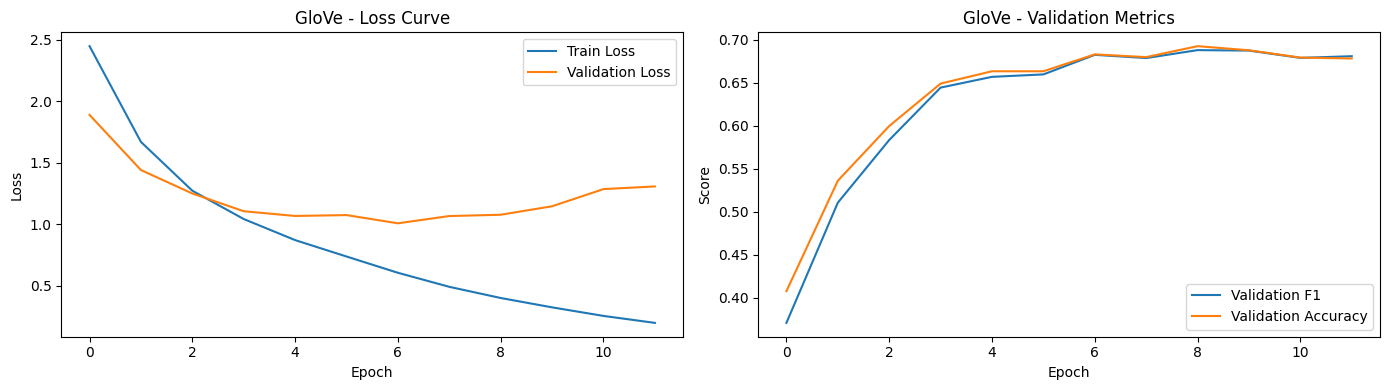

In [91]:
plot_history(history_w2v, "Word2Vec")
plot_history(history_ft, "FastText")
plot_history(history_glove, "GloVe")

## - 기본 실험 결과 비교 및 최고 F1 모델 선택

In [92]:
baseline_summary = pd.DataFrame([
    {"Embedding": "Word2Vec", "Val_Accuracy": val_acc_w2v, "Val_F1": val_f1_w2v},
    {"Embedding": "FastText", "Val_Accuracy": val_acc_ft, "Val_F1": val_f1_ft},
    {"Embedding": "GloVe", "Val_Accuracy": val_acc_glove, "Val_F1": val_f1_glove},
]).sort_values(by="Val_F1", ascending=False)

baseline_summary


,Embedding,Val_Accuracy,Val_F1
0,Word2Vec,0.708223,0.708827
1,FastText,0.696552,0.698166
2,GloVe,0.692308,0.687705


In [93]:
best_embedding_name = baseline_summary.iloc[0]["Embedding"]
print("튜닝 대상(가장 높은 Validation F1-score):", best_embedding_name)

if best_embedding_name == "Word2Vec":
    tuning_embedding_matrix = word2vec_matrix
elif best_embedding_name == "FastText":
    tuning_embedding_matrix = fasttext_matrix
else:
    tuning_embedding_matrix = glove_matrix


튜닝 대상(가장 높은 Validation F1-score): Word2Vec


# 7. 최종 모델 하이퍼파라미터 튜닝

## - 하이퍼파라미터 튜닝

In [94]:
tuning_results = []

dropout_candidates = [0.2, 0.3]
lr_candidates = [1e-3, 5e-4]

for dropout in dropout_candidates:
    for lr in lr_candidates:
        print(f"\n[Tuning] dropout={dropout}, lr={lr}")

        model_tuned, history_tuned, val_acc_tuned, val_f1_tuned = run_rnn_experiment(
            name=f"{best_embedding_name}_Tuning",
            embedding_matrix=tuning_embedding_matrix,
            train_loader=train_loader,
            valid_loader=valid_loader,
            output_dim=len(target_names),
            hidden_dim=512,
            dropout=dropout,
            lr=lr,
            epochs=10,
            freeze_embedding=True
        )

        tuning_results.append({
            "Embedding": best_embedding_name,
            "hidden_dim": 512,
            "dropout": dropout,
            "lr": lr,
            "freeze_embedding": True,
            "val_accuracy": val_acc_tuned,
            "val_f1": val_f1_tuned,
            "history": history_tuned,
            "model": model_tuned
        })



[Tuning] dropout=0.2, lr=0.001
[Word2Vec_Tuning] Epoch 1/10 | Train Loss: 1.8960 | Val Loss: 1.3206 | Val Acc: 0.5926 | Val F1: 0.5721
[Word2Vec_Tuning] Epoch 2/10 | Train Loss: 1.0826 | Val Loss: 1.0210 | Val Acc: 0.6822 | Val F1: 0.6730
[Word2Vec_Tuning] Epoch 3/10 | Train Loss: 0.9179 | Val Loss: 0.9700 | Val Acc: 0.7034 | Val F1: 0.6980
[Word2Vec_Tuning] Epoch 4/10 | Train Loss: 0.8277 | Val Loss: 0.8952 | Val Acc: 0.7305 | Val F1: 0.7242
[Word2Vec_Tuning] Epoch 5/10 | Train Loss: 0.7704 | Val Loss: 0.8969 | Val Acc: 0.7263 | Val F1: 0.7264
[Word2Vec_Tuning] Epoch 6/10 | Train Loss: 0.7102 | Val Loss: 0.8748 | Val Acc: 0.7268 | Val F1: 0.7247
[Word2Vec_Tuning] Epoch 7/10 | Train Loss: 0.6592 | Val Loss: 0.8888 | Val Acc: 0.7252 | Val F1: 0.7260
[Word2Vec_Tuning] Epoch 8/10 | Train Loss: 0.5656 | Val Loss: 0.8603 | Val Acc: 0.7411 | Val F1: 0.7393
[Word2Vec_Tuning] Epoch 9/10 | Train Loss: 0.5281 | Val Loss: 0.8740 | Val Acc: 0.7284 | Val F1: 0.7280
[Word2Vec_Tuning] Epoch 10/10 | 

In [95]:
tuning_df = pd.DataFrame([
    {
        "Embedding": r["Embedding"],
        "hidden_dim": r["hidden_dim"],
        "dropout": r["dropout"],
        "lr": r["lr"],
        "freeze_embedding": r["freeze_embedding"],
        "val_accuracy": r["val_accuracy"],
        "val_f1": r["val_f1"]
    }
    for r in tuning_results
]).sort_values(by="val_f1", ascending=False)

tuning_df


,Embedding,hidden_dim,dropout,lr,freeze_embedding,val_accuracy,val_f1
0,Word2Vec,512,0.2,0.0010,True,0.741114,0.739287
2,Word2Vec,512,0.3,0.0010,True,0.731565,0.731016
3,Word2Vec,512,0.3,0.0005,True,0.729443,0.725619
1,Word2Vec,512,0.2,0.0005,True,0.715119,0.716614


In [96]:
best_tuning_row = tuning_df.iloc[0]
print("Best tuned setting:")
print(best_tuning_row)

best_tuned_result = None
for r in tuning_results:
    if (
        r["hidden_dim"] == best_tuning_row["hidden_dim"]
        and r["dropout"] == best_tuning_row["dropout"]
        and r["lr"] == best_tuning_row["lr"]
        and r["freeze_embedding"] == best_tuning_row["freeze_embedding"]
    ):
        best_tuned_result = r
        break

best_model_tuned = best_tuned_result["model"]
best_history_tuned = best_tuned_result["history"]


Best tuned setting:
Embedding           Word2Vec
hidden_dim               512
dropout                  0.2
lr                     0.001
freeze_embedding        True
val_accuracy        0.741114
val_f1              0.739287
Name: 0, dtype: object


## - 튜닝 전 / 후 비교


In [97]:
if best_embedding_name == "Word2Vec":
    baseline_best_history = history_w2v
elif best_embedding_name == "FastText":
    baseline_best_history = history_ft
else:
    baseline_best_history = history_glove

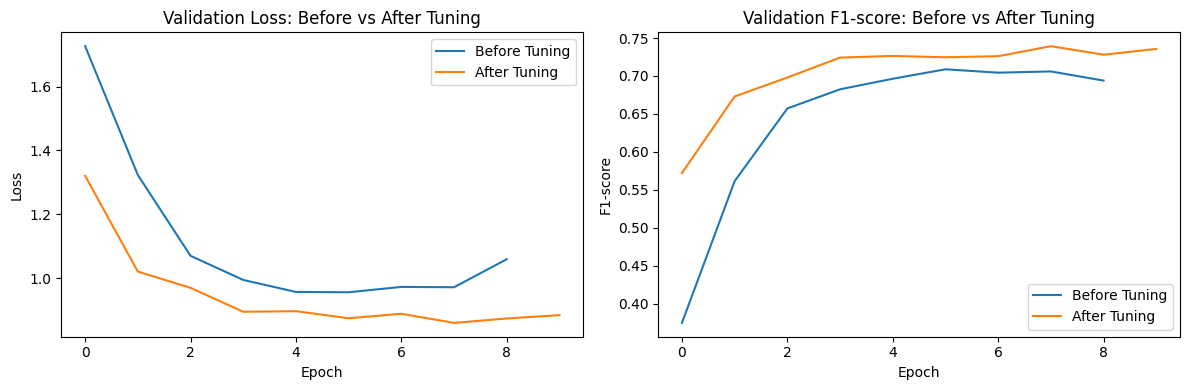

In [98]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(baseline_best_history["val_loss"], label="Before Tuning")
plt.plot(best_history_tuned["val_loss"], label="After Tuning")
plt.title("Validation Loss: Before vs After Tuning")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(baseline_best_history["val_f1"], label="Before Tuning")
plt.plot(best_history_tuned["val_f1"], label="After Tuning")
plt.title("Validation F1-score: Before vs After Tuning")
plt.xlabel("Epoch")
plt.ylabel("F1-score")
plt.legend()

plt.tight_layout()
plt.show()


# 8. 테스트셋 최종 평가

In [99]:
def evaluate_on_test(model, loader):
    criterion = nn.CrossEntropyLoss()
    test_loss, test_acc, test_prec, test_rec, test_f1 = evaluate_loss_and_metrics(model, loader, criterion)
    return {
        "Loss": test_loss,
        "Accuracy": test_acc,
        "Precision": test_prec,
        "Recall": test_rec,
        "F1-score": test_f1
    }

result_w2v = evaluate_on_test(model_w2v, test_loader)
result_ft = evaluate_on_test(model_ft, test_loader)
result_glove = evaluate_on_test(model_glove, test_loader)
result_tuned = evaluate_on_test(best_model_tuned, test_loader)

In [100]:
results = [
    {"Model": "Word2Vec", **result_w2v},
    {"Model": "FastText", **result_ft},
    {"Model": "GloVe", **result_glove},
    {"Model": f"{best_embedding_name}_Tuned", **result_tuned},
]

results_df = pd.DataFrame(results).sort_values(by="F1-score", ascending=False)
results_df


,Model,Loss,Accuracy,Precision,Recall,F1-score
3,Word2Vec_Tuned,0.870547,0.737931,0.751015,0.737931,0.737233
0,Word2Vec,0.935258,0.707427,0.721639,0.707427,0.708278
1,FastText,1.032410,0.700000,0.718696,0.700000,0.703059
2,GloVe,1.091715,0.691512,0.703895,0.691512,0.690068


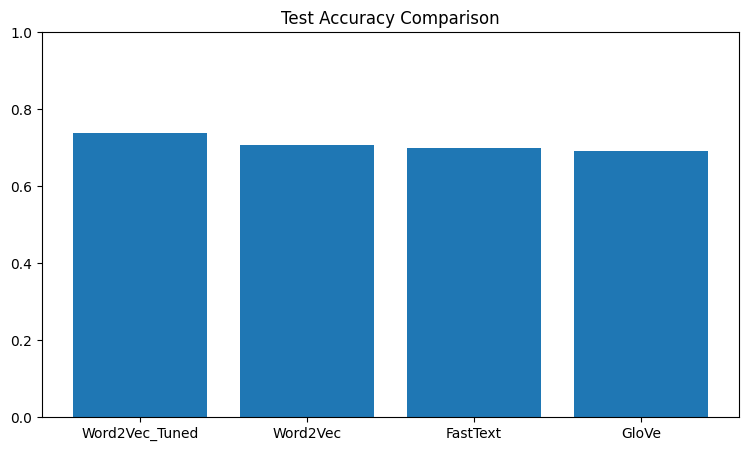

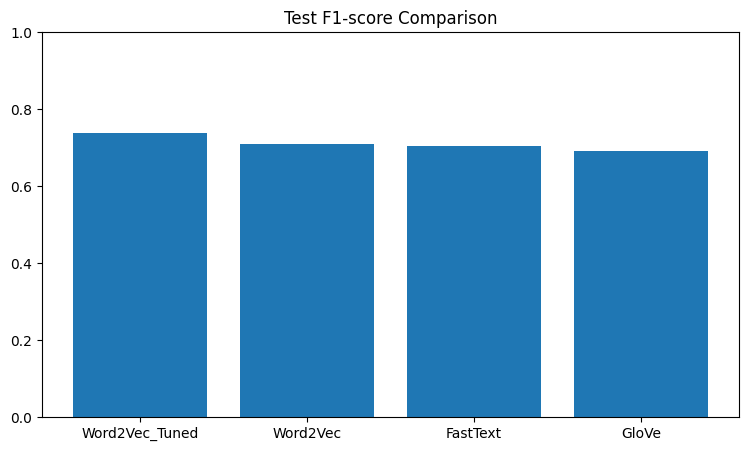

In [101]:
plt.figure(figsize=(9, 5))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.title("Test Accuracy Comparison")
plt.ylim(0, 1.0)
plt.show()

plt.figure(figsize=(9, 5))
plt.bar(results_df["Model"], results_df["F1-score"])
plt.title("Test F1-score Comparison")
plt.ylim(0, 1.0)
plt.show()

In [102]:
final_best_model_name = results_df.iloc[0]["Model"]
print("최종 선택 모델(Test F1-score 기준):", final_best_model_name)

if final_best_model_name == "Word2Vec":
    best_model_final = model_w2v
elif final_best_model_name == "FastText":
    best_model_final = model_ft
elif final_best_model_name == "GloVe":
    best_model_final = model_glove
else:
    best_model_final = best_model_tuned


최종 선택 모델(Test F1-score 기준): Word2Vec_Tuned


# 9. 전체 성능 요약
테스트셋에서 맞춘 개수와 틀린 개수를 확인합니다.

In [106]:
def get_test_predictions(model, loader, device):
    model.eval()
    preds = []

    with torch.no_grad():
        for X_batch, _, len_batch in loader:
            X_batch = X_batch.to(device)
            len_batch = len_batch.to(device)
            outputs = model(X_batch, len_batch)
            batch_preds = torch.argmax(outputs, dim=1).cpu().numpy()
            preds.extend(batch_preds)

    return np.array(preds)

test_preds_final = get_test_predictions(best_model_final, test_loader, device)

true = np.array(test_labels)
pred = np.array(test_preds_final)

total = len(true)
correct = np.sum(true == pred)
wrong = total - correct

acc = accuracy_score(true, pred)
prec, rec, f1, _ = precision_recall_fscore_support(true, pred, average='weighted', zero_division=0)

print("=" * 50)
print("전체 성능 요약")
print("=" * 50)
print(f"전체 샘플 수     : {total}")
print(f"맞춘 개수       : {correct}")
print(f"틀린 개수       : {wrong}")
print("-" * 50)
print(f"Accuracy        : {acc:.4f}")
print(f"Precision       : {prec:.4f}")
print(f"Recall          : {rec:.4f}")
print(f"F1-score        : {f1:.4f}")
print("=" * 50)

전체 성능 요약
전체 샘플 수     : 3770
맞춘 개수       : 2782
틀린 개수       : 988
--------------------------------------------------
Accuracy        : 0.7379
Precision       : 0.7510
Recall          : 0.7379
F1-score        : 0.7372


## - 클래스별 성능 분석

In [104]:
class_total = pd.Series(test_labels).value_counts().sort_index()

class_correct = {}
for class_id in range(len(target_names)):
    mask = (true == class_id)
    class_correct[class_id] = int(np.sum(pred[mask] == true[mask]))

class_rows = []
for class_id, class_name in enumerate(target_names):
    total_count = int(class_total.get(class_id, 0))
    correct_count = int(class_correct.get(class_id, 0))
    wrong_count = total_count - correct_count
    class_acc = correct_count / total_count if total_count > 0 else 0.0

    class_rows.append({
        "class_id": class_id,
        "class_name": class_name,
        "total_count": total_count,
        "correct_count": correct_count,
        "wrong_count": wrong_count,
        "class_accuracy": round(class_acc, 4)
    })

class_result_df = pd.DataFrame(class_rows).sort_values(by="class_accuracy", ascending=False)
class_result_df

,class_id,class_name,total_count,correct_count,wrong_count,class_accuracy
10,10,rec.sport.hockey,200,180,20,0.9000
5,5,comp.windows.x,198,174,24,0.8788
9,9,rec.sport.baseball,199,166,33,0.8342
17,17,talk.politics.mideast,188,155,33,0.8245
7,7,rec.autos,198,163,35,0.8232
13,13,sci.med,198,156,42,0.7879
14,14,sci.space,197,155,42,0.7868
16,16,talk.politics.guns,182,142,40,0.7802
11,11,sci.crypt,198,154,44,0.7778
1,1,comp.graphics,195,146,49,0.7487


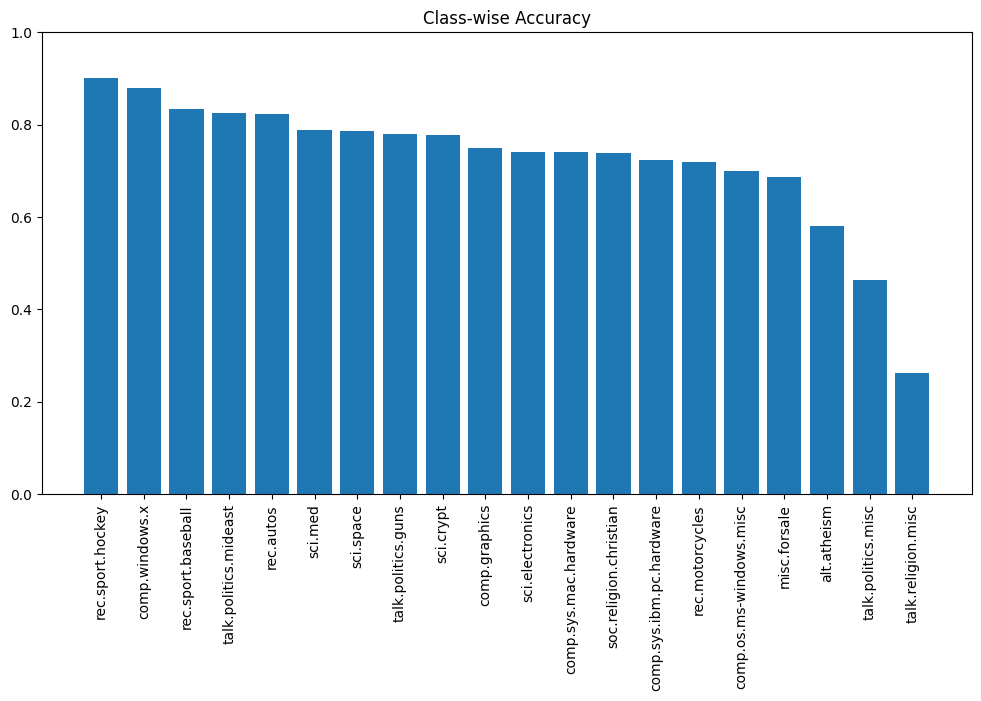

In [107]:
plt.figure(figsize=(12, 6))
plt.bar(class_result_df["class_name"], class_result_df["class_accuracy"])
plt.xticks(rotation=90)
plt.title("Class-wise Accuracy")
plt.ylim(0, 1.0)
plt.show()

## - 결과 분석

In [47]:
# accuracy 낮은 클래스 확인
class_result_df.sort_values(by="class_accuracy", ascending=True).head(10)

,class_id,class_name,total_count,correct_count,wrong_count,class_accuracy
19,19,talk.religion.misc,126,26,100,0.2063
0,0,alt.atheism,160,88,72,0.5500
18,18,talk.politics.misc,155,86,69,0.5548
8,8,rec.motorcycles,199,119,80,0.5980
3,3,comp.sys.ibm.pc.hardware,196,124,72,0.6327
6,6,misc.forsale,195,137,58,0.7026
4,4,comp.sys.mac.hardware,193,143,50,0.7409
2,2,comp.os.ms-windows.misc,197,146,51,0.7411
12,12,sci.electronics,197,150,47,0.7614
1,1,comp.graphics,195,150,45,0.7692


In [48]:
import pandas as pd
import numpy as np

def analyze_confusions_for_class(true, pred, target_names, target_class_name, top_n=10):
    class_id = target_names.index(target_class_name)

    mask = (true == class_id)
    confused_preds = pred[mask]

    confusion_counts = pd.Series(confused_preds).value_counts().sort_values(ascending=False)

    rows = []
    total = mask.sum()

    for pred_class_id, count in confusion_counts.items():
        rows.append({
            "true_class": target_class_name,
            "pred_class": target_names[pred_class_id],
            "count": int(count),
            "ratio_within_true_class": round(count / total, 4)
        })

    result_df = pd.DataFrame(rows)

    print(f"[클래스: {target_class_name}]")
    print(f"전체 샘플 수: {total}")
    print(result_df.head(top_n))

    return result_df

In [49]:
analyze_confusions_for_class(true, pred, target_names, "talk.religion.misc", top_n=10)

[클래스: talk.religion.misc]
전체 샘플 수: 126
           true_class               pred_class  count  ratio_within_true_class
0  talk.religion.misc   soc.religion.christian     41                   0.3254
1  talk.religion.misc              alt.atheism     34                   0.2698
2  talk.religion.misc       talk.religion.misc     26                   0.2063
3  talk.religion.misc       talk.politics.guns     11                   0.0873
4  talk.religion.misc                rec.autos      4                   0.0317
5  talk.religion.misc  comp.os.ms-windows.misc      3                   0.0238
6  talk.religion.misc                sci.space      2                   0.0159
7  talk.religion.misc       talk.politics.misc      2                   0.0159
8  talk.religion.misc          sci.electronics      1                   0.0079
9  talk.religion.misc                sci.crypt      1                   0.0079


,true_class,pred_class,count,ratio_within_true_class
0,talk.religion.misc,soc.religion.christian,41,0.3254
1,talk.religion.misc,alt.atheism,34,0.2698
2,talk.religion.misc,talk.religion.misc,26,0.2063
3,talk.religion.misc,talk.politics.guns,11,0.0873
4,talk.religion.misc,rec.autos,4,0.0317
5,talk.religion.misc,comp.os.ms-windows.misc,3,0.0238
6,talk.religion.misc,sci.space,2,0.0159
7,talk.religion.misc,talk.politics.misc,2,0.0159
8,talk.religion.misc,sci.electronics,1,0.0079
9,talk.religion.misc,sci.crypt,1,0.0079


In [54]:
def analyze_text_length_by_class(texts, labels, target_names):
    rows = []

    for class_id, class_name in enumerate(target_names):
        class_texts = [texts[i] for i in range(len(texts)) if labels[i] == class_id]
        lengths = [len(str(t).split()) for t in class_texts]

        rows.append({
            "class_id": class_id,
            "class_name": class_name,
            "num_samples": len(lengths),
            "avg_length": round(np.mean(lengths), 2) if lengths else 0,
            "median_length": round(np.median(lengths), 2) if lengths else 0,
            "min_length": int(np.min(lengths)) if lengths else 0,
            "max_length": int(np.max(lengths)) if lengths else 0
        })

    return pd.DataFrame(rows).sort_values(by="avg_length", ascending=True)

In [55]:
length_df = analyze_text_length_by_class(test_texts, test_labels, target_names)
length_df

,class_id,class_name,num_samples,avg_length,median_length,min_length,max_length
6,6,misc.forsale,195,87.19,58.0,0,489
7,7,rec.autos,198,90.29,69.0,0,902
8,8,rec.motorcycles,199,93.72,57.0,0,727
2,2,comp.os.ms-windows.misc,197,105.15,69.0,0,966
4,4,comp.sys.mac.hardware,193,107.79,83.0,0,782
12,12,sci.electronics,197,109.75,84.0,0,1758
3,3,comp.sys.ibm.pc.hardware,196,112.91,77.0,0,966
9,9,rec.sport.baseball,199,117.79,69.0,0,902
10,10,rec.sport.hockey,200,137.60,85.0,0,1506
16,16,talk.politics.guns,182,138.43,94.0,0,774


In [56]:
from sklearn.feature_extraction.text import CountVectorizer

def show_top_words_for_class(texts, labels, target_names, target_class_name, top_n=20, min_df=3):
    class_id = target_names.index(target_class_name)
    class_texts = [texts[i] for i in range(len(texts)) if labels[i] == class_id]

    vectorizer = CountVectorizer(stop_words='english', min_df=min_df, max_features=5000)
    X = vectorizer.fit_transform(class_texts)

    word_counts = np.asarray(X.sum(axis=0)).flatten()
    vocab = np.array(vectorizer.get_feature_names_out())

    top_idx = word_counts.argsort()[::-1][:top_n]

    result_df = pd.DataFrame({
        "word": vocab[top_idx],
        "count": word_counts[top_idx]
    })

    print(f"[{target_class_name}] 대표 단어")
    display(result_df)

    return result_df

In [57]:
show_top_words_for_class(train_texts, train_labels, target_names, "talk.religion.misc", top_n=20)

[talk.religion.misc] 대표 단어


,word,count
0,god,476
1,jesus,298
2,people,287
3,don,193
4,bible,192
5,say,183
6,just,183
7,know,177
8,christian,168
9,lord,165


,word,count
0,god,476
1,jesus,298
2,people,287
3,don,193
4,bible,192
5,say,183
6,just,183
7,know,177
8,christian,168
9,lord,165


In [60]:
def diagnose_low_accuracy_class(
    target_class_name,
    train_texts, train_labels,
    test_texts, test_labels,
    true, pred, target_names,
    top_n_errors=5
):
    print("=" * 120)
    print(f"[진단 대상 클래스] {target_class_name}")
    print("=" * 120)

    class_id = target_names.index(target_class_name)

    train_count = np.sum(np.array(train_labels) == class_id)
    test_count = np.sum(np.array(test_labels) == class_id)

    mask = (true == class_id)
    total = np.sum(mask)
    correct = np.sum(pred[mask] == true[mask])
    wrong = total - correct
    acc = correct / total if total > 0 else 0

    print(f"train_count : {train_count}")
    print(f"test_count  : {test_count}")
    print(f"correct     : {correct}")
    print(f"wrong       : {wrong}")
    print(f"class_acc   : {acc:.4f}")

    print("\n[1] 어떤 클래스로 자주 헷갈리는가")
    confusion_df = analyze_confusions_for_class(true, pred, target_names, target_class_name, top_n=10)

    print("\n[2] 대표 단어")
    top_words_df = show_top_words_for_class(train_texts, train_labels, target_names, target_class_name, top_n=20)

    print("\n[3] 오답 샘플")
    show_misclassified_samples(test_texts, true, pred, target_names, target_class_name, n=top_n_errors)

    return confusion_df, top_words_df

In [61]:
diagnose_low_accuracy_class(
    target_class_name="talk.religion.misc",
    train_texts=train_texts,
    train_labels=train_labels,
    test_texts=test_texts,
    test_labels=test_labels,
    true=true,
    pred=pred,
    target_names=target_names,
    top_n_errors=5
)

[진단 대상 클래스] talk.religion.misc
train_count : 439
test_count  : 126
correct     : 26
wrong       : 100
class_acc   : 0.2063

[1] 어떤 클래스로 자주 헷갈리는가
[클래스: talk.religion.misc]
전체 샘플 수: 126
           true_class               pred_class  count  ratio_within_true_class
0  talk.religion.misc   soc.religion.christian     41                   0.3254
1  talk.religion.misc              alt.atheism     34                   0.2698
2  talk.religion.misc       talk.religion.misc     26                   0.2063
3  talk.religion.misc       talk.politics.guns     11                   0.0873
4  talk.religion.misc                rec.autos      4                   0.0317
5  talk.religion.misc  comp.os.ms-windows.misc      3                   0.0238
6  talk.religion.misc                sci.space      2                   0.0159
7  talk.religion.misc       talk.politics.misc      2                   0.0159
8  talk.religion.misc          sci.electronics      1                   0.0079
9  talk.religion.misc     

,word,count
0,god,476
1,jesus,298
2,people,287
3,don,193
4,bible,192
5,say,183
6,just,183
7,know,177
8,christian,168
9,lord,165



[3] 오답 샘플
[talk.religion.misc] 오답 샘플 수: 100
[1] index: 33
TRUE: talk.religion.misc
PRED: talk.politics.guns
----------------------------------------------------------------------------------------------------

Yeah. Innocents. People who hoard $250K worth of high-caliber automatic weapons
and kill law-enforcement agents really fit the bill here. The only innocents
were the 20+ children who were prevented from leaving a burning building by
their self-appointed messiah-following parents. A burning STARTED by the 
Davidians.



Is this subject line a veiled threat against U.S. Government agents or possibly
Executive office leadership (i.e. Clinton)? I've considered you a bit of a loon,
before, Stephen, I guess this pretty much confirms it. 

Nice religion you have there.  The only ones who should be killed are those who
don't agree with us. Sheesh.


-- 
--------------------------------------------------------------------------------Tom Hyatt                                  I'm a diehar

(            true_class               pred_class  count  \
 0   talk.religion.misc   soc.religion.christian     41   
 1   talk.religion.misc              alt.atheism     34   
 2   talk.religion.misc       talk.religion.misc     26   
 3   talk.religion.misc       talk.politics.guns     11   
 4   talk.religion.misc                rec.autos      4   
 5   talk.religion.misc  comp.os.ms-windows.misc      3   
 6   talk.religion.misc                sci.space      2   
 7   talk.religion.misc       talk.politics.misc      2   
 8   talk.religion.misc          sci.electronics      1   
 9   talk.religion.misc                sci.crypt      1   
 10  talk.religion.misc                  sci.med      1   
 
     ratio_within_true_class  
 0                    0.3254  
 1                    0.2698  
 2                    0.2063  
 3                    0.0873  
 4                    0.0317  
 5                    0.0238  
 6                    0.0159  
 7                    0.0159  
 8         

## - 오류 분석

talk.religion.misc 클래스는 전체 테스트 데이터 126개 중 26개만 정확히 분류되어, 약 20.6%의 낮은 정확도를 보였다. 이는 전체 클래스 중에서도 비교적 분류 난이도가 높은 클래스임을 의미한다.

1. 주요 오분류 경향

- soc.religion.christian (32.5%)
- alt.atheism (27.0%)

즉, 전체 오답의 약 60%가 종교 관련 클래스 간의 혼동에서 발생하였다.

2. 원인 분석

(1) 클래스 간 경계 모호성
talk.religion.misc는 특정 종교에 국한되지 않고 다양한 종교, 철학, 논쟁적 주제를 포함하는 혼합 클래스이다.  
반면 soc.religion.christian은 기독교 중심, alt.atheism은 무신론 중심으로 비교적 명확한 주제를 가진다.

이로 인해 모델이 해당 문서를 특정 종교나 철학적 입장으로 해석하면서 오분류가 발생하였다.

---

(2) 단어 분포

- god, jesus, bible, christian, christ

이러한 단어들은 talk.religion.misc뿐 아니라  
soc.religion.christian, alt.atheism에서도 공통적으로 등장한다.

즉, 단어 임베딩 기반 모델에서는 클래스 간 구분이 어려운 구조이다.

---

(3) 문맥 기반 분류의 한계

오답 샘플을 보면 단순한 종교 텍스트가 아니라 정치, 역사, 문화와 같은 다양한 주제가 혼합된 경우가 많았다.

이러한 경우 모델은 단어보다는 문맥에 따라 talk.politics.guns, alt.atheism, sci.space 등으로 분류되었다.


# 10. 결과 분석 및 결론


텍스트 분류 성능 향상을 위해 전처리, 모델 비교, 하이퍼파라미터 튜닝을 단계적으로 수행하였다.

---

1. 실험 결과 요약

- Word2Vec의 튜닝된 모델이 전체 샘플 수 3770개중 2782개를 맞춰 Accuracy : 0.7379, F1-score: 0.7372 의 결과로 성능이 가장 좋았다.
- 하지만 일부 클래스에서 정확도가 매우 낮은 문제가 발생하였다.
- 특히 `talk.religion.misc` 클래스는  
  - 다른 종교 관련 클래스(`soc.religion.christian`, `alt.atheism`)와  
  - 높은 비율로 혼동되는 경향을 보였다.

---

2. 성능 저하의 주요 원인

분석 결과, 다음과 같은 문제가 성능 저하의 핵심 원인으로 확인되었다.

(1) 클래스 간 의미적 유사성
- 종교 관련 클래스들은 사용하는 단어와 문맥이 매우 유사함
- 모델이 클래스 간 경계를 명확히 구분하지 못함

(2) 데이터 불균형
- 클래스별 데이터 수 차이가 존재하여  
  일부 클래스가 충분히 학습되지 못함

(3) 전처리의 한계
- 기존 전처리는 일반적인 정제 수준에 머물러 있음
- 문맥 정보나 의미 차이를 충분히 반영하지 못함

---

3. 개선 방향

성능 향상을 위해 다음과 같은 개선이 필요하다.

(1) 전처리 강화
- 불용어 제거 최적화
- 표제어 추출(Lemmatization) 적용
- 의미를 보존하는 방향의 텍스트 정제

(2) 데이터 보완
- 소수 클래스 데이터 증강
- 클래스 불균형 완화

(3) 모델 개선
- 문맥 이해가 가능한 모델 (BERT, Transformer 계열) 적용
- 클래스 간 미세한 의미 차이를 반영할 수 있는 구조 필요

---

4. 최종 결론

본 프로젝트를 통해 단순한 모델 선택이나 튜닝만으로는 성능 향상에 한계가 있으며,  

데이터 특성(유사성, 불균형)과 전처리 품질이 성능에 큰 영향을 미친다는 점을 확인하였다.

특히,
- 클래스 간 경계가 모호한 경우
- 전처리 및 데이터 품질 개선이 핵심적인 역할을 한다.

향후에는  데이터 중심(Data-Centric) 접근 혹은 문맥 이해가 가능한 BERT, Transformer 계열을 기반으로 성능 개선을 진행해 볼 수 있을것이다.